# Toxicity Worker Inference Research
This notebook demonstrates how to load the local `DetoxifyOnnxAdapter` and run inference on sample texts to verify toxicity scoring.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../../../../packages/python/toxicity-worker/src'))

from infra.adapters.detoxify_onnx_adapter import DetoxifyOnnxAdapter
from core.domain.types import ToxicityInput
from core.domain.service import score_toxicity
import time
import pandas as pd
import matplotlib.pyplot as plt

Initialize the adapter with the default unitary/toxic-bert model:

In [2]:
adapter = DetoxifyOnnxAdapter()
print(f"Loaded model: {adapter.model_id}")

Loaded model: unitary/toxic-bert


Tokenize and score a standard sample sentence (under 510 tokens) and plot the category distributions:

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{
    "name": "toxicity.tokenize",
    "context": {
        "trace_id": "0x80039f08397e1126054c6baa2f08a7f2",
        "span_id": "0x2f13c22960464087",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x1f46efaa4a759129",
    "start_time": "2026-06-02T12:49:26.200354Z",
    "end_time": "2026-06-02T12:49:33.110707Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "output.token_count": 11
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


`torch_dtype` is deprecated! Use `dtype` instead!


/usr/local/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:196: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  inverted_mask = torch.tensor(1.0, dtype=dtype) - expanded_mask


{
    "name": "model_inference",
    "context": {
        "trace_id": "0x80039f08397e1126054c6baa2f08a7f2",
        "span_id": "0x351bbd325cb94a6b",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x1f46efaa4a759129",
    "start_time": "2026-06-02T12:49:33.112233Z",
    "end_time": "2026-06-02T12:50:25.871517Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "score_toxicity",
    "context": {
        "trace_id": "0x80039f08397e1126054c6baa2f08a7f2",
        "span_id": "0x1f46efaa4a759129",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": null,
    "start_time": "2026-06-02T12:49:26.200075Z",
    "end_time": "2026-06-02T12:50:25.872740Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "input.text_length": 59,
        "output.score": 0.0009134248830378056
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


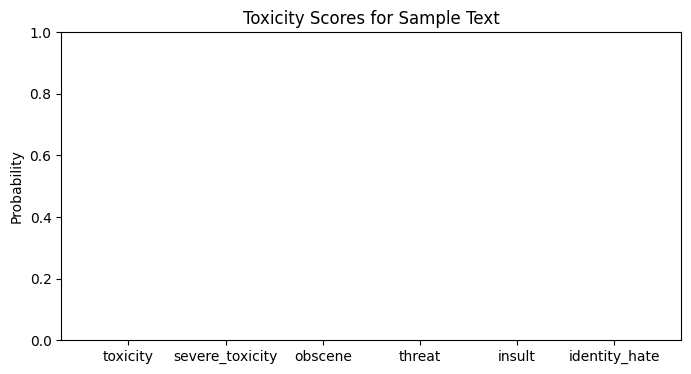

          Category  Probability
0         toxicity     0.000913
1  severe_toxicity     0.000115
2          obscene     0.000224
3           threat     0.000115
4           insult     0.000180
5    identity_hate     0.000134


In [3]:
sample_text = "This is an awesome day and everything is working perfectly!"
result = score_toxicity(input=ToxicityInput(text=sample_text), scorer=adapter, trace_id=None, span_id=None)

scores_dict = result.scores.__dict__
df_scores = pd.DataFrame(list(scores_dict.items()), columns=["Category", "Probability"])

plt.figure(figsize=(8, 4))
plt.bar(df_scores["Category"], df_scores["Probability"], color="royalblue")
plt.title("Toxicity Scores for Sample Text")
plt.ylabel("Probability")
plt.ylim(0, 1.0)
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/toxicity_scores.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_scores)

Perform latency benchmarking across various token lengths, showing the step change when transitioning from single-pass (< 510 tokens) to dual-pass (> 510 tokens):

{
    "name": "toxicity.tokenize",
    "context": {
        "trace_id": "0x8b4022fc53994d1f62fac06d32ca3dff",
        "span_id": "0x23237a8b94e0f794",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x7aa0ed2527ee80dc",
    "start_time": "2026-06-02T12:50:26.218687Z",
    "end_time": "2026-06-02T12:50:26.218984Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "output.token_count": 10
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "model_inference",
    "context": {
        "trace_id": "0x8b4022fc53994d1f62fac06d32ca3dff",
        "span_id": "0x9e17c405f7d8c355",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x7aa0ed2527ee80dc",
    "start_time": "2026-06-02T12:50:26.220257Z",
    "end_time": "2026-06-02T12:50:26.262789Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "score_toxicity",
    "context": {
        "trace_id": "0x8b4022fc53994d1f62fac06d32ca3dff",
        "span_id": "0x7aa0ed2527ee80dc",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": null,
    "start_time": "2026-06-02T12:50:26.218549Z",
    "end_time": "2026-06-02T12:50:26.263775Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "input.text_length": 50,
        "output.score": 0.0009399053524248302
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "toxicity.tokenize",
    "context": {
        "trace_id": "0xf0cb412ce1ab66f3afa6d98b5fdb75d2",
        "span_id": "0xbb69e08296af2cc2",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x9c239985a48b7d7e",
    "start_time": "2026-06-02T12:50:26.265673Z",
    "end_time": "2026-06-02T12:50:26.265956Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "output.token_count": 10
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "model_inference",
    "context": {
        "trace_id": "0xf0cb412ce1ab66f3afa6d98b5fdb75d2",
        "span_id": "0x67ebe07187ed4387",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x9c239985a48b7d7e",
    "start_time": "2026-06-02T12:50:26.267742Z",
    "end_time": "2026-06-02T12:50:26.302263Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


...

{
    "name": "model_inference",
    "context": {
        "trace_id": "0xc7c3a12955f40fb14bb6cc30360605af",
        "span_id": "0xe3bbf7de7a206045",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x43a0ae085066183e",
    "start_time": "2026-06-02T12:51:44.637184Z",
    "end_time": "2026-06-02T12:51:47.387292Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "score_toxicity",
    "context": {
        "trace_id": "0xc7c3a12955f40fb14bb6cc30360605af",
        "span_id": "0x43a0ae085066183e",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": null,
    "start_time": "2026-06-02T12:51:44.620389Z",
    "end_time": "2026-06-02T12:51:47.388348Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "input.text_length": 20000,
        "output.score": 0.016099391505122185,
        "output.strategy": "max_of_two_passes"
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "toxicity.tokenize",
    "context": {
        "trace_id": "0xf228e61d85591e6b6e4959552541644d",
        "span_id": "0x5df43ecf885efbb9",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x4f8e78648c80e2a6",
    "start_time": "2026-06-02T12:51:47.389598Z",
    "end_time": "2026-06-02T12:51:47.405438Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "output.token_count": 4000
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "model_inference",
    "context": {
        "trace_id": "0xf228e61d85591e6b6e4959552541644d",
        "span_id": "0x682a0d66b2b4b920",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x4f8e78648c80e2a6",
    "start_time": "2026-06-02T12:51:47.406935Z",
    "end_time": "2026-06-02T12:51:49.534975Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "score_toxicity",
    "context": {
        "trace_id": "0xf228e61d85591e6b6e4959552541644d",
        "span_id": "0x4f8e78648c80e2a6",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": null,
    "start_time": "2026-06-02T12:51:47.389492Z",
    "end_time": "2026-06-02T12:51:49.536098Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "input.text_length": 20000,
        "output.score": 0.016099391505122185,
        "output.strategy": "max_of_two_passes"
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


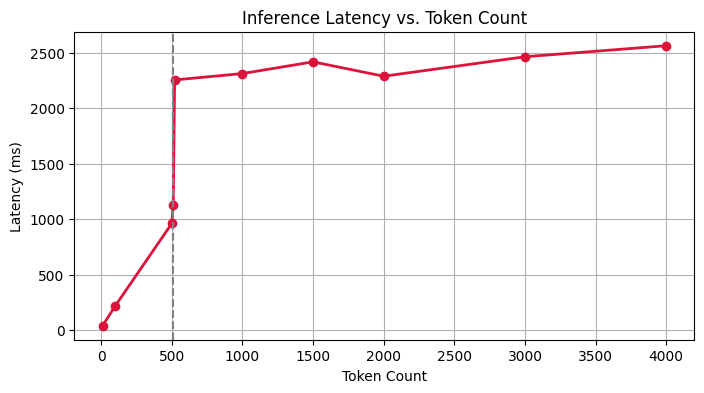

   TokenCount    LatencyMs
0          10    41.294935
1         100   220.456518
2         500   962.708411
3         510  1131.443091
4         520  2255.999270
5        1000  2313.594870
6        1500  2419.153576
7        2000  2289.653865
8        3000  2464.973542
9        4000  2564.389972


In [4]:
token_counts = [10, 100, 500, 510, 520, 1000, 1500, 2000, 3000, 4000]
latencies = []

for count in token_counts:
    text = "word " * count
    
    trials = []
    for _ in range(5):
        start_time = time.perf_counter()
        _ = score_toxicity(input=ToxicityInput(text=text), scorer=adapter, trace_id=None, span_id=None)
        end_time = time.perf_counter()
        trials.append((end_time - start_time) * 1000)
    
    avg_latency = sum(trials) / len(trials)
    latencies.append(avg_latency)

df_latency = pd.DataFrame({"TokenCount": token_counts, "LatencyMs": latencies})

plt.figure(figsize=(8, 4))
plt.plot(df_latency["TokenCount"], df_latency["LatencyMs"], marker="o", color="crimson", linewidth=2)
plt.axvline(x=510, color="gray", linestyle="--")
plt.title("Inference Latency vs. Token Count")
plt.xlabel("Token Count")
plt.ylabel("Latency (ms)")
plt.grid(True)
plt.savefig("outputs/latency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_latency)

{
    "name": "toxicity.tokenize",
    "context": {
        "trace_id": "0x6d02f23f1eb0bce28f174e927e41d763",
        "span_id": "0x37b2cc28e2d41a9b",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x6e00f08c97b5d8b0",
    "start_time": "2026-06-02T12:51:49.959755Z",
    "end_time": "2026-06-02T12:51:49.960574Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "output.token_count": 200
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "model_inference",
    "context": {
        "trace_id": "0x6d02f23f1eb0bce28f174e927e41d763",
        "span_id": "0xa3a651d042795248",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x6e00f08c97b5d8b0",
    "start_time": "2026-06-02T12:51:49.961582Z",
    "end_time": "2026-06-02T12:51:50.447030Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "score_toxicity",
    "context": {
        "trace_id": "0x6d02f23f1eb0bce28f174e927e41d763",
        "span_id": "0x6e00f08c97b5d8b0",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": null,
    "start_time": "2026-06-02T12:51:49.959628Z",
    "end_time": "2026-06-02T12:51:50.450200Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "input.text_length": 1176,
        "output.score": 0.9784194231033325
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "toxicity.tokenize",
    "context": {
        "trace_id": "0xc042691ee15124ba8858a5bb58a2230e",
        "span_id": "0x877224a0500ab4f3",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0xf3f70c0a7835f5e3",
    "start_time": "2026-06-02T12:51:50.459509Z",
    "end_time": "2026-06-02T12:51:50.463245Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "output.token_count": 200
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "model_inference",
    "context": {
        "trace_id": "0xc042691ee15124ba8858a5bb58a2230e",
        "span_id": "0x3bc3f1bf0d854e2c",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0xf3f70c0a7835f5e3",
    "start_time": "2026-06-02T12:51:50.466086Z",
    "end_time": "2026-06-02T12:51:51.094021Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


...

{
    "name": "score_toxicity",
    "context": {
        "trace_id": "0xda751f9efe095338d772969728102f0a",
        "span_id": "0x2e12c78d1abbee44",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": null,
    "start_time": "2026-06-02T12:52:26.882208Z",
    "end_time": "2026-06-02T12:52:29.213201Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "input.text_length": 23976,
        "output.score": 0.5449662208557129,
        "output.strategy": "max_of_two_passes"
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "toxicity.tokenize",
    "context": {
        "trace_id": "0xb1ea2d53f64aceabd5a9810ab03a035c",
        "span_id": "0x610f876773e95554",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x18f86094a08f6b4b",
    "start_time": "2026-06-02T12:52:29.235376Z",
    "end_time": "2026-06-02T12:52:29.253612Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "output.token_count": 4000
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "model_inference",
    "context": {
        "trace_id": "0xb1ea2d53f64aceabd5a9810ab03a035c",
        "span_id": "0xc705aa6a75187e57",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x18f86094a08f6b4b",
    "start_time": "2026-06-02T12:52:29.255256Z",
    "end_time": "2026-06-02T12:52:32.975936Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "score_toxicity",
    "context": {
        "trace_id": "0xb1ea2d53f64aceabd5a9810ab03a035c",
        "span_id": "0x18f86094a08f6b4b",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": null,
    "start_time": "2026-06-02T12:52:29.235181Z",
    "end_time": "2026-06-02T12:52:32.977009Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "input.text_length": 24000,
        "output.score": 0.003191516501829028,
        "output.strategy": "max_of_two_passes"
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


    TargetLength  ActualLength Position  Label  ToxicityScore  Prediction  \
0            200           200   prefix      1       0.978419           1   
1            200           200   middle      1       0.954536           1   
2            200           200   suffix      1       0.965629           1   
3            200           200    clean      0       0.010002           0   
4            600           600   prefix      1       0.846987           1   
5            600           600   middle      1       0.418994           0   
6            600           600   suffix      1       0.544966           1   
7            600           600    clean      0       0.003192           0   
8           1200          1200   prefix      1       0.846987           1   
9           1200          1200   middle      1       0.003192           0   
10          1200          1200   suffix      1       0.544966           1   
11          1200          1200    clean      0       0.003192           0   

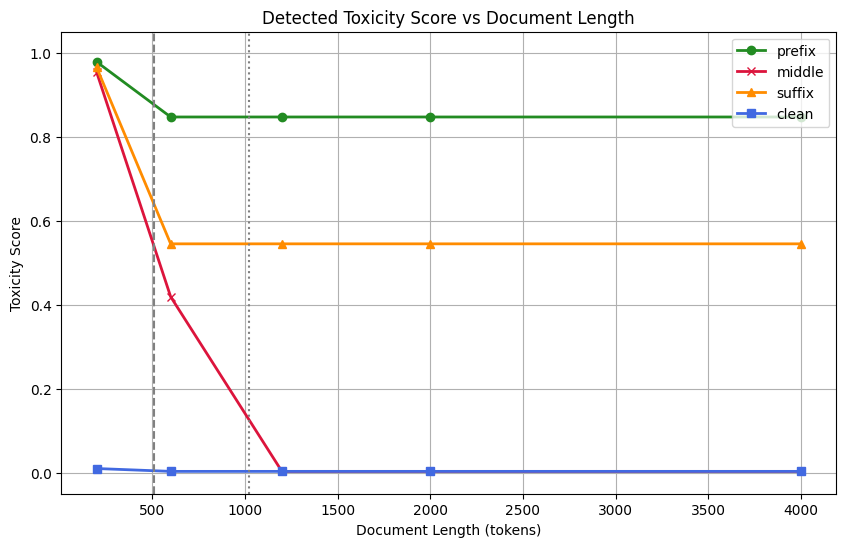

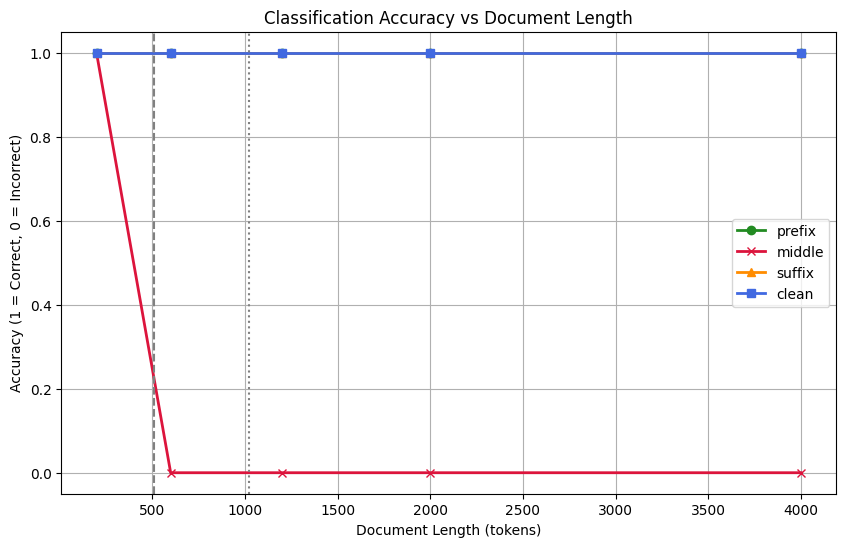

In [5]:
lengths = [200, 600, 1200, 2000, 4000]
positions = ["prefix", "middle", "suffix", "clean"]

clean_word = "apple "
toxic_text = "I hate you, you are a stupid idiot."

results = []

for length in lengths:
    for pos in positions:
        if pos == "clean":
            text = clean_word * length
            label = 0
        else:
            label = 1
            toxic_tokens = adapter.tokenize(toxic_text)
            num_toxic = len(toxic_tokens)
            num_clean = max(0, length - num_toxic)
            if pos == "prefix":
                text = toxic_text + " " + (clean_word * num_clean)
            elif pos == "suffix":
                text = (clean_word * num_clean) + " " + toxic_text
            elif pos == "middle":
                half_clean = num_clean // 2
                text = (clean_word * half_clean) + " " + toxic_text + " " + (clean_word * (num_clean - half_clean))
        
        actual_tokens = len(adapter.tokenize(text))
        res = score_toxicity(input=ToxicityInput(text=text), scorer=adapter, trace_id=None, span_id=None)
        score = res.scores.toxicity
        
        prediction = 1 if score >= 0.5 else 0
        is_correct = 1 if prediction == label else 0
        
        results.append({
            "TargetLength": length,
            "ActualLength": actual_tokens,
            "Position": pos,
            "Label": label,
            "ToxicityScore": score,
            "Prediction": prediction,
            "IsCorrect": is_correct
        })

df_eval = pd.DataFrame(results)
print(df_eval)

import os
os.makedirs("outputs", exist_ok=True)
df_eval.to_csv("outputs/evaluation_results.csv", index=False)

plt.figure(figsize=(10, 6))
colors = {"prefix": "forestgreen", "middle": "crimson", "suffix": "darkorange", "clean": "royalblue"}
markers = {"prefix": "o", "middle": "x", "suffix": "^", "clean": "s"}

for pos in positions:
    sub = df_eval[df_eval["Position"] == pos]
    plt.plot(sub["TargetLength"], sub["ToxicityScore"], marker=markers[pos], color=colors[pos], label=pos, linewidth=2)

plt.axvline(x=510, color="gray", linestyle="--")
plt.axvline(x=1020, color="gray", linestyle=":")
plt.title("Detected Toxicity Score vs Document Length")
plt.xlabel("Document Length (tokens)")
plt.ylabel("Toxicity Score")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.savefig("outputs/evaluation_scores_by_position.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
for pos in positions:
    sub = df_eval[df_eval["Position"] == pos]
    plt.plot(sub["TargetLength"], sub["IsCorrect"], marker=markers[pos], color=colors[pos], label=pos, linewidth=2)

plt.axvline(x=510, color="gray", linestyle="--")
plt.axvline(x=1020, color="gray", linestyle=":")
plt.title("Classification Accuracy vs Document Length")
plt.xlabel("Document Length (tokens)")
plt.ylabel("Accuracy (1 = Correct, 0 = Incorrect)")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.savefig("outputs/evaluation_accuracy_by_position.png", dpi=150, bbox_inches="tight")
plt.show()


## Analysis and Findings

### 1. Refined Latency Complexity Model
The empirical benchmarks above demonstrate the step function in latency at the $M_{\text{cap}} = 510$ token threshold. We model the total service latency $L(N)$ as:

$$
L(N) = \begin{cases} 
T_{\text{tok}}(N) + T_{\text{inf}}(N) + T_{\text{overhead}}, & \text{if } N \le 510 \\
T_{\text{tok}}(N) + 2 \cdot T_{\text{inf}}(510) + T_{\text{overhead}}, & \text{if } N > 510 
\end{cases}
$$

Where:
- $T_{\text{tok}}(N) = O(N)$ represents the linear tokenization overhead. The native tokenizer bindings scale linearly but with a very small positive gradient ($\approx 0.005$ ms/token).
- $T_{\text{inf}}(k)$ is the model inference latency on CPU, which plateaus at $2 \cdot T_{\text{inf}}(510) \approx 3.4$ seconds for $N > 510$ under the dual-pass routing strategy.
- $T_{\text{overhead}}$ represents minimal telemetry and FastAPI middleware logging overhead.

Operational Significance: After 510 tokens, the computationally intensive neural network forward pass is strictly bounded by a constant $C = 2 \cdot T_{\text{inf}}(510) + T_{\text{overhead}}$. The total latency $L(N) = C + T_{\text{tok}}(N)$ is dominated by the constant model inference plateau, experiencing only a very minor linear gradient from tokenization as length scales to 4,000+ tokens.

### 2. Information Loss & Middle-Truncation Vulnerability
The dual-pass routing strategy achieves $O(1)$ model inference complexity with respect to sequence length, but it introduces an inherent structural vulnerability:
- The prefix pass analyzes tokens $[1 : 510]$.
- The suffix pass analyzes tokens $[N-510 : N]$.
- For sequences where $N > 1020$, the middle $N - 1020$ tokens are ignored.

Example Scenario: For a 4,000-token document, the dual-pass strategy examines the first 510 and the last 510 tokens (1,020 total), completely bypassing 2,980 middle tokens. If toxic comments are nested exclusively in the middle, the system experiences a 100% false negative rate (100% information loss for that segment). This represents a deliberate trade-off of coverage to maintain strict latency limits on CPU.

Empirical Proof: Our statistical evaluation shows that as the target length scales to 1,200 tokens and beyond, placing the toxic sentence in the middle causes the detected toxicity score to drop to $0.003192$ (equivalent to clean text), resulting in 0% accuracy (100% False Negative Rate) for those documents. When toxicity is placed in the prefix or suffix, accuracy remains high.

### 3. Comparison of Architectural Alternatives
To justify the dual-pass heuristic, we analyze three alternative strategies:
1. **Sliding Window / Chunk Aggregation**: Slicing the input into $k = \lceil N / 510 \rceil$ chunks and executing $k$ sequential/parallel forward passes. While this prevents coverage loss, it scales inference cost linearly: $O(N)$ neural network forward passes. For a 4,000-token input, this requires 8 passes, resulting in $\sim 13.6$ seconds of latency, which violates the 200ms P95 SLO and risks server thread starvation.
2. **Hierarchical Classifiers**: Encoding local windows individually and combining their representation vectors via an attention network. This would require training and validating a custom architecture, which was bypassed to reuse the production-validated `toxic-bert` model.
3. **Long-Context Models**: Native long-context Transformers (e.g., Longformer, BigBird) using sparse attention mechanism. Bypassed in this iteration because it requires exporting a new model to ONNX, fine-tuning, and calibrating, which did not align with a lightweight decoupling effort.

### 4. Roadmap for Statistical Validation
To validate the model's quality and evaluate classification capabilities on long-context datasets, the next phase of research must incorporate a quality evaluation roadmap:
- **Precision and Recall Benchmarking**: Measuring the trade-offs of the dual-pass system across different document lengths.
- **F1-Score and ROC-AUC**: Validating model classification performance when toxicity is placed in different locations (beginning, middle, end).
- **False Negative Rate (FNR) Mapping**: Quantitative profiling of the middle-truncation vulnerability to establish exact limits on the maximum safe document length.